In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import numpy as np

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_35170/3336189524.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(beta_distribution(x, alpha, beta), x)


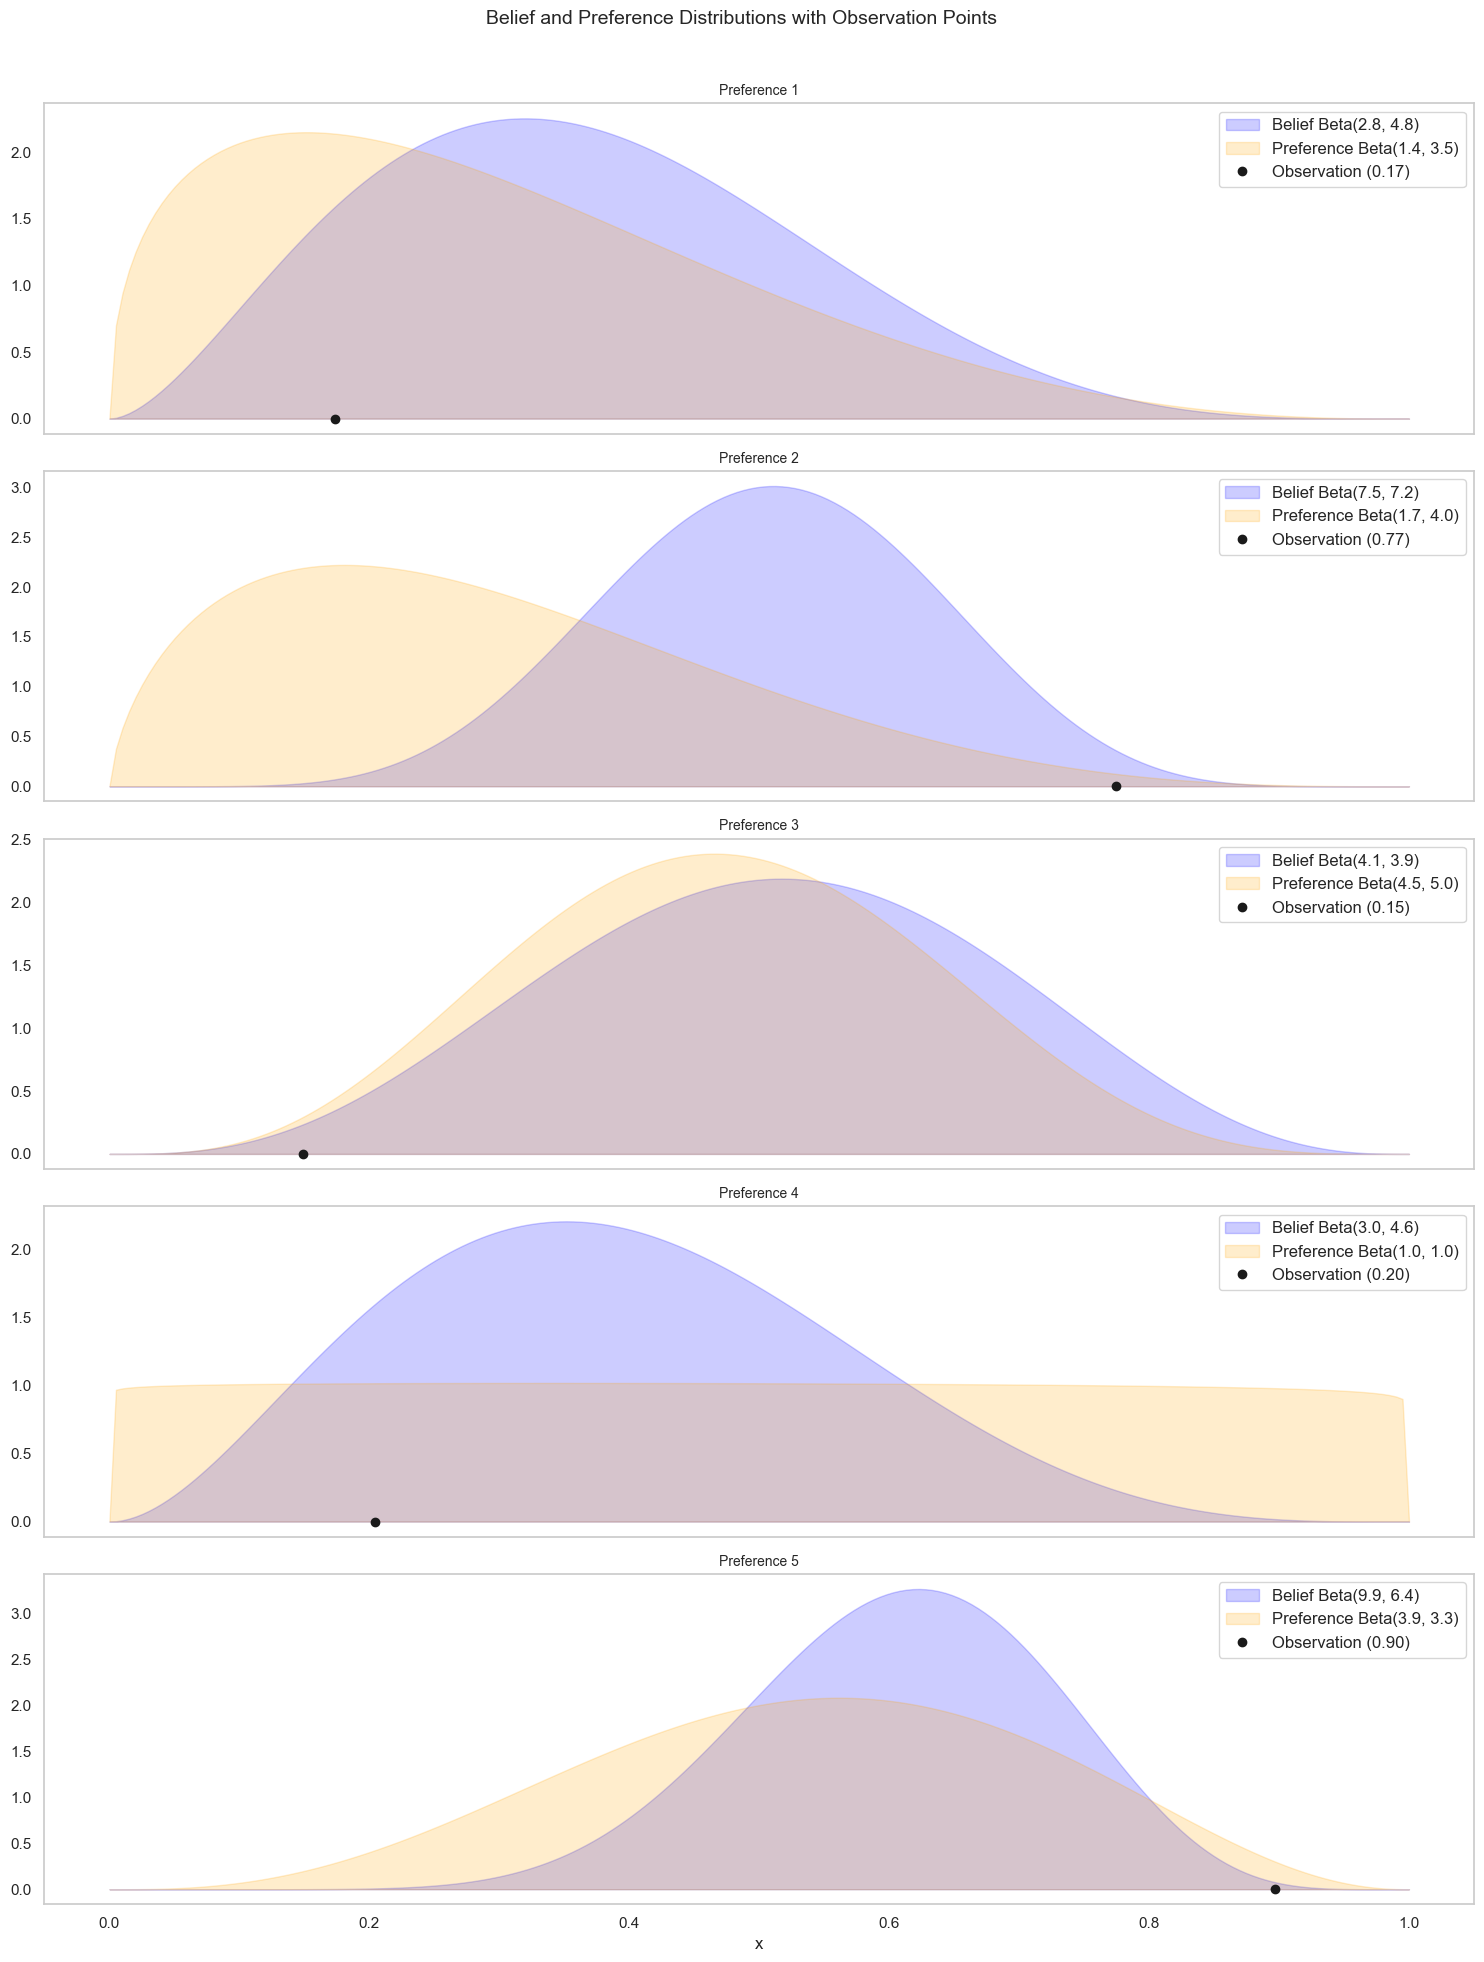

In [20]:
# Define and normalize beta distribution
def beta_distribution(x, alpha, beta):
    return (x ** (alpha - 1)) * ((1 - x) ** (beta - 1))


def normalize_distribution(x, alpha, beta):
    norm = np.trapz(beta_distribution(x, alpha, beta), x)
    return beta_distribution(x, alpha, beta) / norm


# Parameters
x = np.linspace(0, 1, 200)
n_subplots = 5
alphas_belief = np.random.uniform(2, 10, size=n_subplots)
betas_belief = np.random.uniform(2, 10, size=n_subplots)
alphas_pref = np.random.uniform(1, 5, size=n_subplots)
betas_pref = np.random.uniform(1, 5, size=n_subplots)
observations = np.random.uniform(0, 1, size=n_subplots)

# Plot
fig_height = n_subplots * 4
fig, axs = plt.subplots(n_subplots, 1, figsize=(15, fig_height), sharex=True)

for i in range(n_subplots):
    belief = normalize_distribution(x, alphas_belief[i], betas_belief[i])
    pref = normalize_distribution(x, alphas_pref[i], betas_pref[i])
    obs = observations[i]

    axs[i].fill_between(
        x,
        belief,
        alpha=0.2,
        color="blue",
        label=f"Belief Beta({alphas_belief[i]:.1f}, {betas_belief[i]:.1f})",
    )

    axs[i].fill_between(
        x,
        pref,
        alpha=0.2,
        color="orange",
        label=f"Preference Beta({alphas_pref[i]:.1f}, {betas_pref[i]:.1f})",
    )

    axs[i].plot(obs, 0, "ko", label=f"Observation ({obs:.2f})")

    axs[i].legend(fontsize=12)
    axs[i].set_title(f"Preference {i + 1}", fontsize=10)
    axs[i].grid(False)
    fig.suptitle(
        "Belief and Preference Distributions with Observation Points", fontsize=14
    )
plt.xlabel("x")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

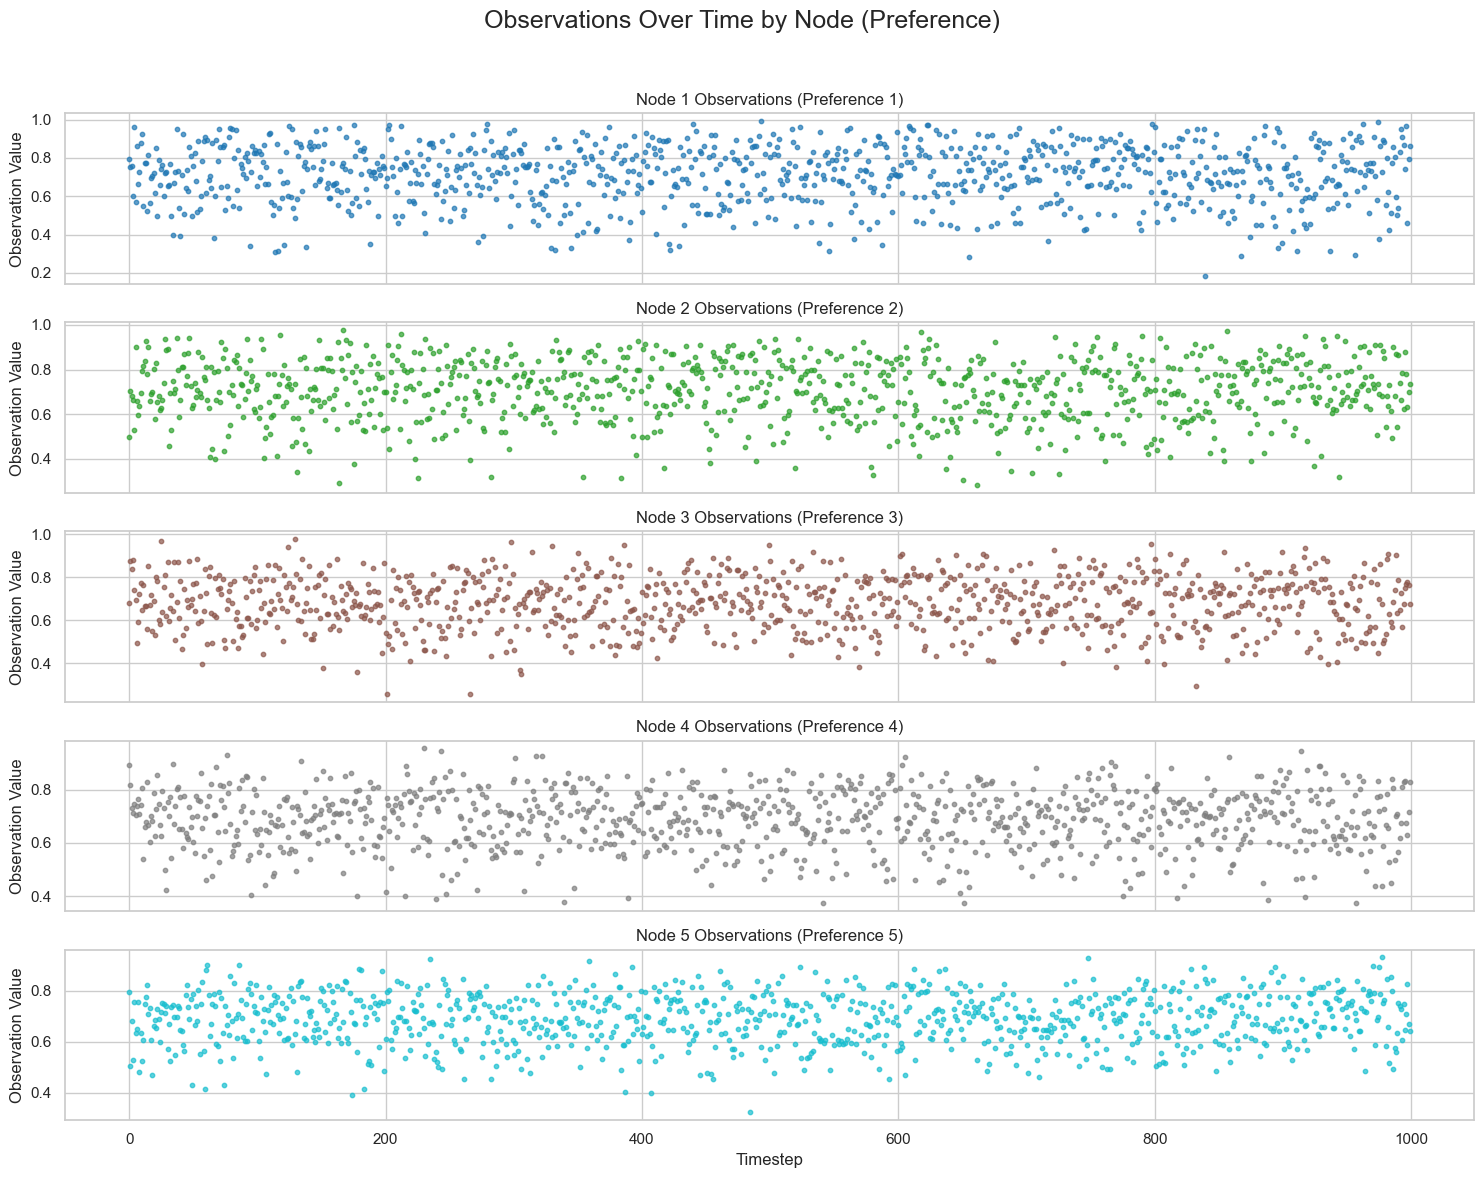

In [27]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

time_steps = np.arange(1000)
n_nodes = 5

obs_nodes = [np.random.beta(a=5 + i * 2, b=2 + i, size=1000) for i in range(n_nodes)]

fig, axs = plt.subplots(n_nodes, 1, figsize=(15, 12), sharex=True)

colors = plt.cm.tab10(np.linspace(0, 1, n_nodes))

for i in range(n_nodes):
    axs[i].scatter(time_steps, obs_nodes[i], s=10, alpha=0.7, color=colors[i])
    axs[i].set_title(f"Node {i + 1} Observations (Preference {i + 1})")
    axs[i].set_ylabel("Observation Value")

axs[-1].set_xlabel("Timestep")
fig.suptitle("Observations Over Time by Node (Preference)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()